# 03 — Descriptive statistics

Pre-registered in `PREREGISTRATION.md` (section 7): mean `card_diff`, `cpf_diff` and `foul_diff` per crowd category, 2017/18–2022/23, with 95% confidence intervals clustered by referee.

These are **raw means** — no control for team strength or trend. The models come in notebook 04.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
pd.set_option("display.width", 200)

matches = pd.read_csv(PROCESSED_DIR / "matches_elo.csv", parse_dates=["Date"])
analysis = matches[matches["season_start"] >= 2017].copy()
print(analysis.shape)
analysis["crowd"].value_counts()

(2280, 28)


crowd
full       1808
ghost       437
partial      35
Name: count, dtype: int64

## 1. Means with clustered confidence intervals

Matches refereed by the same person are not independent (each referee has a personal style), so the usual confidence interval would be too narrow.
We get the mean and its clustered CI in one step: regress the outcome on the three category dummies with no constant — each coefficient is then simply the category mean — and cluster standard errors by referee.

In [2]:
CATEGORIES = ["full", "ghost", "partial"]
OUTCOMES = ["card_diff", "cpf_diff", "foul_diff"]


def category_means(data, outcome):
    """Mean of `outcome` per crowd category with a 95% CI clustered by referee."""
    data = data.dropna(subset=[outcome])
    model = smf.ols(f"{outcome} ~ C(crowd) - 1", data=data).fit(
        cov_type="cluster", cov_kwds={"groups": pd.factorize(data["Referee"])[0]}
    )
    ci = model.conf_int()
    rows = []
    for category in CATEGORIES:
        name = f"C(crowd)[{category}]"
        rows.append({
            "outcome": outcome,
            "crowd": category,
            "matches": int((data["crowd"] == category).sum()),
            "mean": model.params[name],
            "ci_low": ci.loc[name, 0],
            "ci_high": ci.loc[name, 1],
        })
    return pd.DataFrame(rows)


means = pd.concat([category_means(analysis, outcome) for outcome in OUTCOMES], ignore_index=True)
means.round(3)

,outcome,crowd,matches,mean,ci_low,ci_high
0,card_diff,full,1808,0.162,0.079,0.244
1,card_diff,ghost,437,-0.027,-0.155,0.100
2,card_diff,partial,35,0.514,0.012,1.017
3,cpf_diff,full,1796,0.015,0.008,0.022
4,cpf_diff,ghost,435,0.007,-0.005,0.019
5,cpf_diff,partial,34,0.061,0.007,0.114
6,foul_diff,full,1808,0.279,0.022,0.537
7,foul_diff,ghost,437,-0.535,-0.960,-0.111
8,foul_diff,partial,35,-0.371,-1.824,1.081


In [3]:
# Raw difference ghost minus full, per outcome (no controls yet)
pivot = means.pivot(index="outcome", columns="crowd", values="mean")
pivot["ghost_minus_full"] = pivot["ghost"] - pivot["full"]
pivot.round(3)

crowd,full,ghost,partial,ghost_minus_full
outcome,,,,
card_diff,0.162,-0.027,0.514,-0.189
cpf_diff,0.015,0.007,0.061,-0.008
foul_diff,0.279,-0.535,-0.371,-0.815


## 2. Figure 1: means by crowd category

Three panels, one per outcome: they are on different scales, so each gets its own axis.

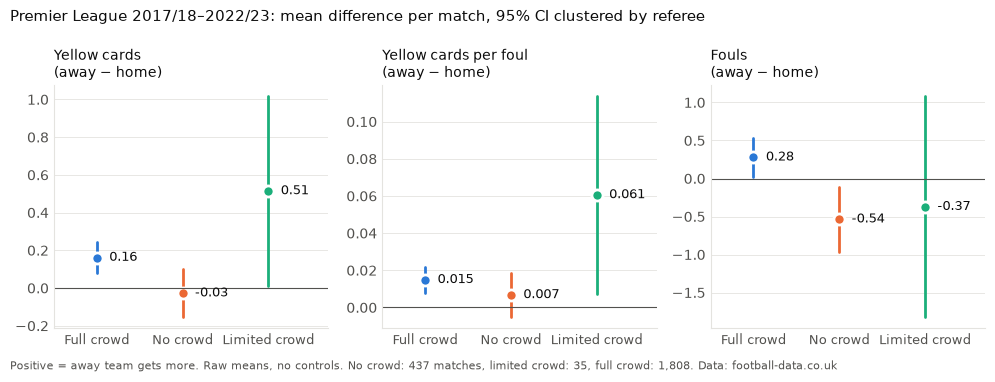

In [4]:
# Colours: validated categorical palette, first three slots (blue, orange, aqua)
COLORS = {"full": "#2a78d6", "ghost": "#eb6834", "partial": "#1baf7a"}
TEXT = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID = "#e4e3df"

plt.rcParams.update({
    "font.size": 10,
    "axes.edgecolor": GRID,
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TITLES = {
    "card_diff": "Yellow cards\n(away − home)",
    "cpf_diff": "Yellow cards per foul\n(away − home)",
    "foul_diff": "Fouls\n(away − home)",
}
LABELS = {"full": "Full crowd", "ghost": "No crowd", "partial": "Limited crowd"}

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))

for ax, outcome in zip(axes, OUTCOMES):
    rows = means[means["outcome"] == outcome].reset_index(drop=True)
    for i, row in rows.iterrows():
        color = COLORS[row["crowd"]]
        ax.plot([i, i], [row["ci_low"], row["ci_high"]], color=color, linewidth=2, solid_capstyle="round")
        ax.plot(i, row["mean"], "o", markersize=8, color=color, markeredgecolor="white", markeredgewidth=2)
        decimals = 3 if outcome == "cpf_diff" else 2
        ax.annotate(f"{row['mean']:.{decimals}f}", (i, row["mean"]), xytext=(9, 0), textcoords="offset points",
                    va="center", fontsize=9, color=TEXT)
    ax.axhline(0, color=TEXT_SECONDARY, linewidth=0.8)
    ax.set_xticks(range(3), [LABELS[c] for c in CATEGORIES], fontsize=9)
    ax.set_xlim(-0.5, 2.7)
    ax.set_title(TITLES[outcome], fontsize=10, color=TEXT, loc="left")
    ax.grid(axis="y", color=GRID, linewidth=0.6)
    ax.tick_params(length=0)

fig.suptitle("Premier League 2017/18–2022/23: mean difference per match, 95% CI clustered by referee",
             fontsize=11, color=TEXT, x=0.01, ha="left")
fig.text(0.01, -0.02, "Positive = away team gets more. Raw means, no controls. "
         "No crowd: 437 matches, limited crowd: 35, full crowd: 1,808. Data: football-data.co.uk",
         fontsize=8, color=TEXT_SECONDARY)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_means_by_crowd.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## 3. Figure 2: card difference season by season

Shows the long-run trend, which matters for the model (`trend`, `var`). Season 2019/20 is split into the part with fans and the closed-door restart.
The 35 limited-crowd matches of 2020/21 are left out of this figure.

In [5]:
def period_label(row):
    if row["crowd"] == "partial":
        return None
    label = row["season"]
    if row["season_start"] == 2019:
        label += " restart" if row["ghost"] == 1 else " pre-Covid"
    return label


all_seasons = matches.copy()
all_seasons["period"] = all_seasons.apply(period_label, axis=1)
all_seasons = all_seasons.dropna(subset=["period"])

period_order = list(dict.fromkeys(all_seasons.sort_values("Date")["period"]))
model = smf.ols("card_diff ~ C(period) - 1", data=all_seasons).fit(
    cov_type="cluster", cov_kwds={"groups": pd.factorize(all_seasons["Referee"])[0]}
)
ci = model.conf_int()

by_period = pd.DataFrame({
    "period": period_order,
    "mean": [model.params[f"C(period)[{p}]"] for p in period_order],
    "ci_low": [ci.loc[f"C(period)[{p}]", 0] for p in period_order],
    "ci_high": [ci.loc[f"C(period)[{p}]", 1] for p in period_order],
    "matches": [int((all_seasons["period"] == p).sum()) for p in period_order],
    "ghost": [int(all_seasons.loc[all_seasons["period"] == p, "ghost"].iloc[0]) for p in period_order],
})
by_period.round(3)

,period,mean,ci_low,ci_high,matches,ghost
0,2010/11,0.426,0.294,0.559,380,0
1,2011/12,0.347,0.161,0.533,380,0
2,2012/13,0.411,0.264,0.557,380,0
3,2013/14,0.332,0.157,0.506,380,0
4,2014/15,0.332,0.093,0.570,380,0
5,2015/16,0.208,0.098,0.318,380,0
6,2016/17,0.142,0.011,0.273,380,0
7,2017/18,0.087,-0.059,0.232,380,0
8,2018/19,0.158,0.013,0.303,380,0
9,2019/20 pre-Covid,0.247,0.065,0.429,288,0


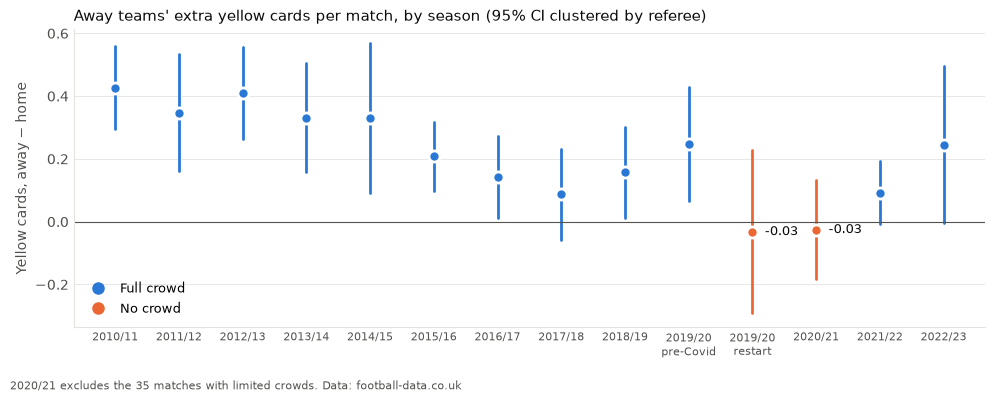

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.8))

for i, row in by_period.iterrows():
    color = COLORS["ghost"] if row["ghost"] else COLORS["full"]
    ax.plot([i, i], [row["ci_low"], row["ci_high"]], color=color, linewidth=2, solid_capstyle="round")
    ax.plot(i, row["mean"], "o", markersize=8, color=color, markeredgecolor="white", markeredgewidth=2)

for i, row in by_period[by_period["ghost"] == 1].iterrows():
    ax.annotate(f"{row['mean']:.2f}", (i, row["mean"]), xytext=(9, 0), textcoords="offset points",
                va="center", fontsize=9, color=TEXT)

ax.axhline(0, color=TEXT_SECONDARY, linewidth=0.8)
ax.set_xticks(range(len(by_period)), by_period["period"].str.replace(" ", "\n"), fontsize=8)
ax.set_ylabel("Yellow cards, away − home")
ax.grid(axis="y", color=GRID, linewidth=0.6)
ax.tick_params(length=0)

handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=8, color=COLORS[c]) for c in ["full", "ghost"]]
ax.legend(handles, ["Full crowd", "No crowd"], frameon=False, loc="lower left", fontsize=9)
ax.set_title("Away teams' extra yellow cards per match, by season (95% CI clustered by referee)",
             fontsize=11, color=TEXT, loc="left")
fig.text(0.01, -0.04, "2020/21 excludes the 35 matches with limited crowds. Data: football-data.co.uk",
         fontsize=8, color=TEXT_SECONDARY)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_card_diff_by_season.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()